category            0
price               0
quantity            0
order_date          0
shipping_date       0
delivery_status     0
payment_method      0
device_type         0
channel             0
customer_segment    0
order_month         0
order_day           0
order_hour          0
shipping_month      0
shipping_day        0
shipping_hour       0
delivery_time       0
dtype: int64

📊 Final Dataset Shape: (10000, 17)


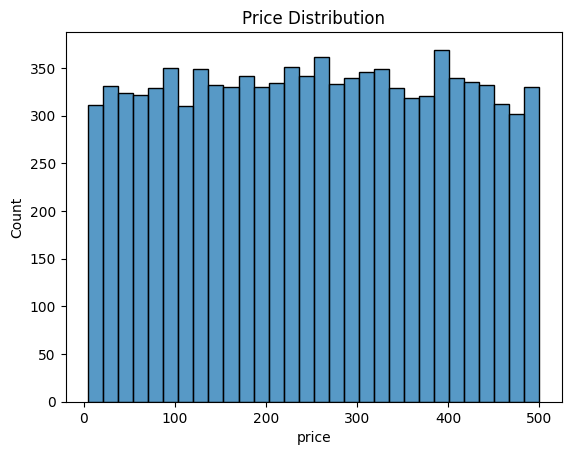

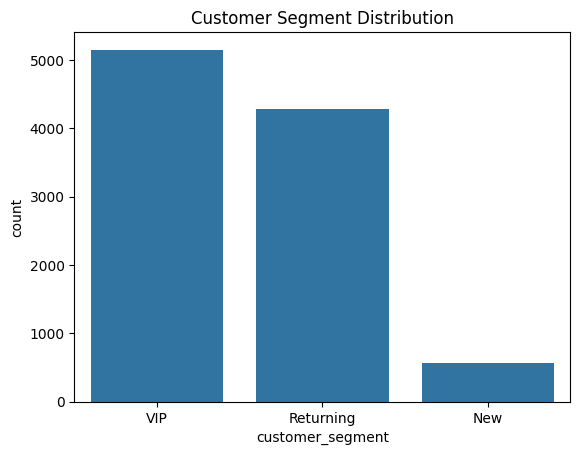

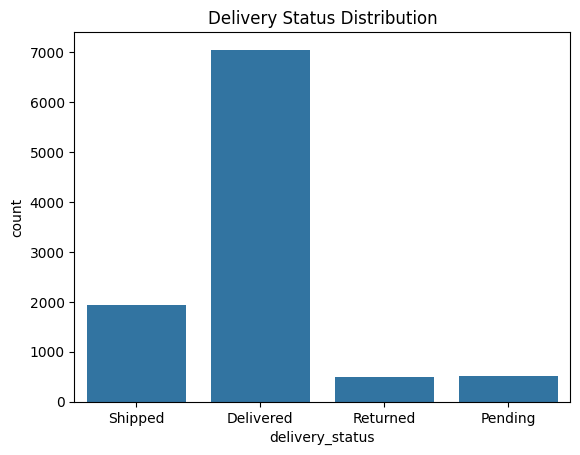

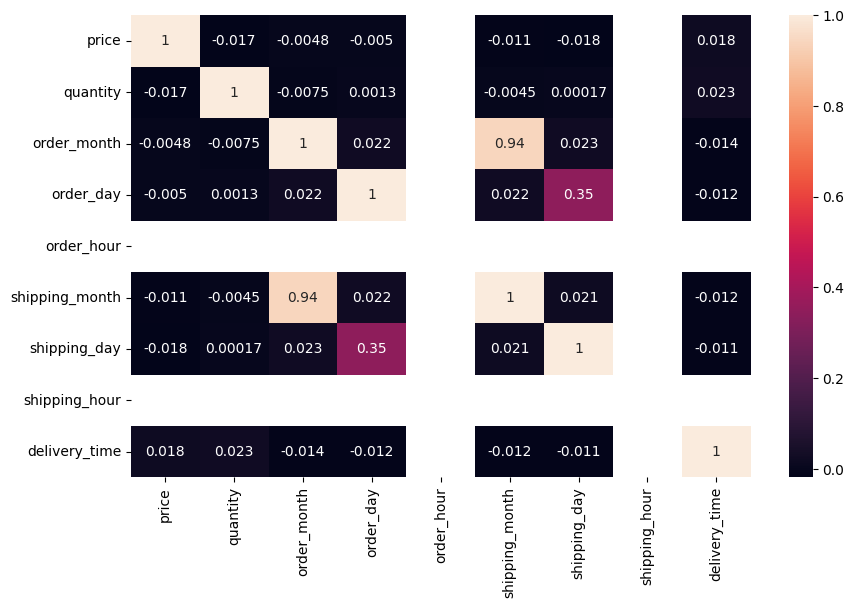

['../artifacts/preprocessor.joblib']

In [11]:
import pandas as pd
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
import os

# ---------------------------------------
# load unclear csv dataset 
# ---------------------------------------  
df = pd.read_csv("../data/ecommerce_order.csv")

# ---------------------------------------
# drop useless columns 
# ---------------------------------------
df = df.drop([
    "order_id", "customer_id", "product_id", "shipping_address", "billing_address" 
], axis=1)

# ---------------------------------------
# convert dates
# ---------------------------------------
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["shipping_date"] = pd.to_datetime(df["shipping_date"], errors="coerce")

# ---------------------------------------
# extract features
# ---------------------------------------
df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["order_hour"] = df["order_date"].dt.hour

df["shipping_month"] = df["shipping_date"].dt.month
df["shipping_day"] = df["shipping_date"].dt.day
df["shipping_hour"] = df["shipping_date"].dt.hour

# ---------------------------------------
# create delivery delay feature
# ---------------------------------------
df["delivery_time"] = (df["shipping_date"] - df["order_date"]).dt.days

# ---------------------------------------
# remove invalid values
# ---------------------------------------
df = df[df["delivery_time"] >= 0]

# ---------------------------------------
# drop null values
# ---------------------------------------
print(df.isnull().sum())
df = df.dropna()
df = df.drop_duplicates()
print("\n📊 Final Dataset Shape:", df.shape)

# ---------------------------------------
# save the cleaned csv
# ---------------------------------------
os.makedirs("../data/", exist_ok=True)
df.to_csv("../data/cleaned_ecommerce_order.csv")

# ---------------------------------------
# visualize price distributaion
# ---------------------------------------
sns.histplot(df["price"], bins=30)
plt.title("Price Distribution")
plt.show()

# ---------------------------------------
# customer segment distribution
# ---------------------------------------
sns.countplot(x="customer_segment", data=df)
plt.title("Customer Segment Distribution")
plt.show()

# ---------------------------------------
# delivery stauts distribution
# ---------------------------------------
sns.countplot(x="delivery_status", data=df)
plt.title("Delivery Status Distribution")
plt.show()

# ---------------------------------------
# Correlation Matrix
# ---------------------------------------
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()

# ---------------------------------------
# build preprocessing pipeline
# ---------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df.drop(columns=["price"])

categorical_features = [
    "category",
    "payment_method",
    "device_type",
    "channel"
]

numerical_features = [
    "quantity",
    "delivery_time",
    "order_month",
    "order_day"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# ---------------------------------------
# dump the preprocessor 
# ---------------------------------------
joblib.dump(preprocessor, "../artifacts/preprocessor.joblib")



ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['quantity', 'delivery_time', 'order_month',
                                  'order_day']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['category', 'payment_method', 'device_type',
                                  'channel'])])
